#🛠️ Preparación de los Datos

In [83]:
#importando las bibliotecas a usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
#Leyendo el dataset
url="https://raw.githubusercontent.com/SergioptsUSCO/Challenge-Telecom-X---Parte-2/refs/heads/main/datos.csv"
df = pd.read_csv(url,index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   int64  
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   int64  
 5   Dependents        7267 non-null   int64  
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   int64  
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 
 17  

In [85]:
#Eliminando columnas innecesarias
df=df.drop(columns=["customerID","charges.daily"])

In [86]:
#Tratando valores nulos
df["Charges.Total"]=df['Charges.Total'].fillna(0)
df['gender']

,gender
0,Female
1,Male
2,Male
3,Male
4,Female
...,...
7262,Female
7263,Male
7264,Male
7265,Male


In [119]:
#Codificando variables categóricas
df_codificados = pd.get_dummies(df, drop_first=True)
df_codificados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Churn                                  7267 non-null   int64  
 1   SeniorCitizen                          7267 non-null   int64  
 2   Partner                                7267 non-null   int64  
 3   Dependents                             7267 non-null   int64  
 4   tenure                                 7267 non-null   int64  
 5   PhoneService                           7267 non-null   int64  
 6   PaperlessBilling                       7267 non-null   int64  
 7   Charges.Monthly                        7267 non-null   float64
 8   Charges.Total                          7267 non-null   float64
 9   gender_Male                            7267 non-null   bool   
 10  MultipleLines_1                        7267 non-null   bool   
 11  MultipleL

In [88]:
#Proporcion de Cancelación(Churn)
df_codificados.Churn.value_counts()    # Se puede ver que hay una gran proporcion de clientes que decidieron no cancelar

,count
Churn,
0,5398
1,1869


In [89]:
#Balanceando las clases en Churn
from imblearn.over_sampling import SMOTE     #despues de analizar las opciones, decidí usar SMOTE para balancear las clases de Churn
X = df_codificados.drop("Churn", axis=1)
y = df_codificados["Churn"]
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
y_balanced.value_counts()

,count
Churn,
0,5398
1,5398


In [93]:
#Normalizando y estandarizando los datos
columnas=df_codificados.columns
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler_standard=StandardScaler()
data_padre=pd.DataFrame(scaler_standard.fit_transform(df_codificados),columns=columnas)
data_padre.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.588421,-0.440736,1.032309,1.527075,-0.950200,0.32829,0.828063,0.029206,-0.742291,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,1.945268,-0.561723,-0.524534,-0.712075,1.834275
1,-0.588421,-0.440736,-0.968702,-0.654847,-0.950200,0.32829,-1.207638,-0.159990,-0.764729,0.988643,...,-0.527306,-0.789421,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275
2,1.699463,-0.440736,-0.968702,-0.654847,-1.153700,0.32829,0.828063,0.304702,-0.880026,0.988643,...,-0.527306,-0.789421,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
3,1.699463,2.268932,1.032309,-0.654847,-0.787401,0.32829,0.828063,1.104635,-0.458160,0.988643,...,-0.527306,1.266752,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
4,1.699463,2.268932,1.032309,-0.654847,-1.194400,0.32829,0.828063,0.636624,-0.885955,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275


In [95]:
#Normalizando
scaler_MinMax=MinMaxScaler()
data_norm=pd.DataFrame(scaler_standard.fit_transform(df_codificados),columns=columnas)
data_norm.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.588421,-0.440736,1.032309,1.527075,-0.950200,0.32829,0.828063,0.029206,-0.742291,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,1.945268,-0.561723,-0.524534,-0.712075,1.834275
1,-0.588421,-0.440736,-0.968702,-0.654847,-0.950200,0.32829,-1.207638,-0.159990,-0.764729,0.988643,...,-0.527306,-0.789421,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275
2,1.699463,-0.440736,-0.968702,-0.654847,-1.153700,0.32829,0.828063,0.304702,-0.880026,0.988643,...,-0.527306,-0.789421,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
3,1.699463,2.268932,1.032309,-0.654847,-0.787401,0.32829,0.828063,1.104635,-0.458160,0.988643,...,-0.527306,1.266752,-0.527306,1.257223,-0.527306,-0.514068,-0.561723,-0.524534,1.404346,-0.545175
4,1.699463,2.268932,1.032309,-0.654847,-1.194400,0.32829,0.828063,0.636624,-0.885955,-1.011487,...,-0.527306,1.266752,-0.527306,-0.795404,-0.527306,-0.514068,-0.561723,-0.524534,-0.712075,1.834275


#🎯 Correlación y Selección de Variables

In [113]:
#Hallando correlacion entre variables
correlaciones=df_codificados.corr()

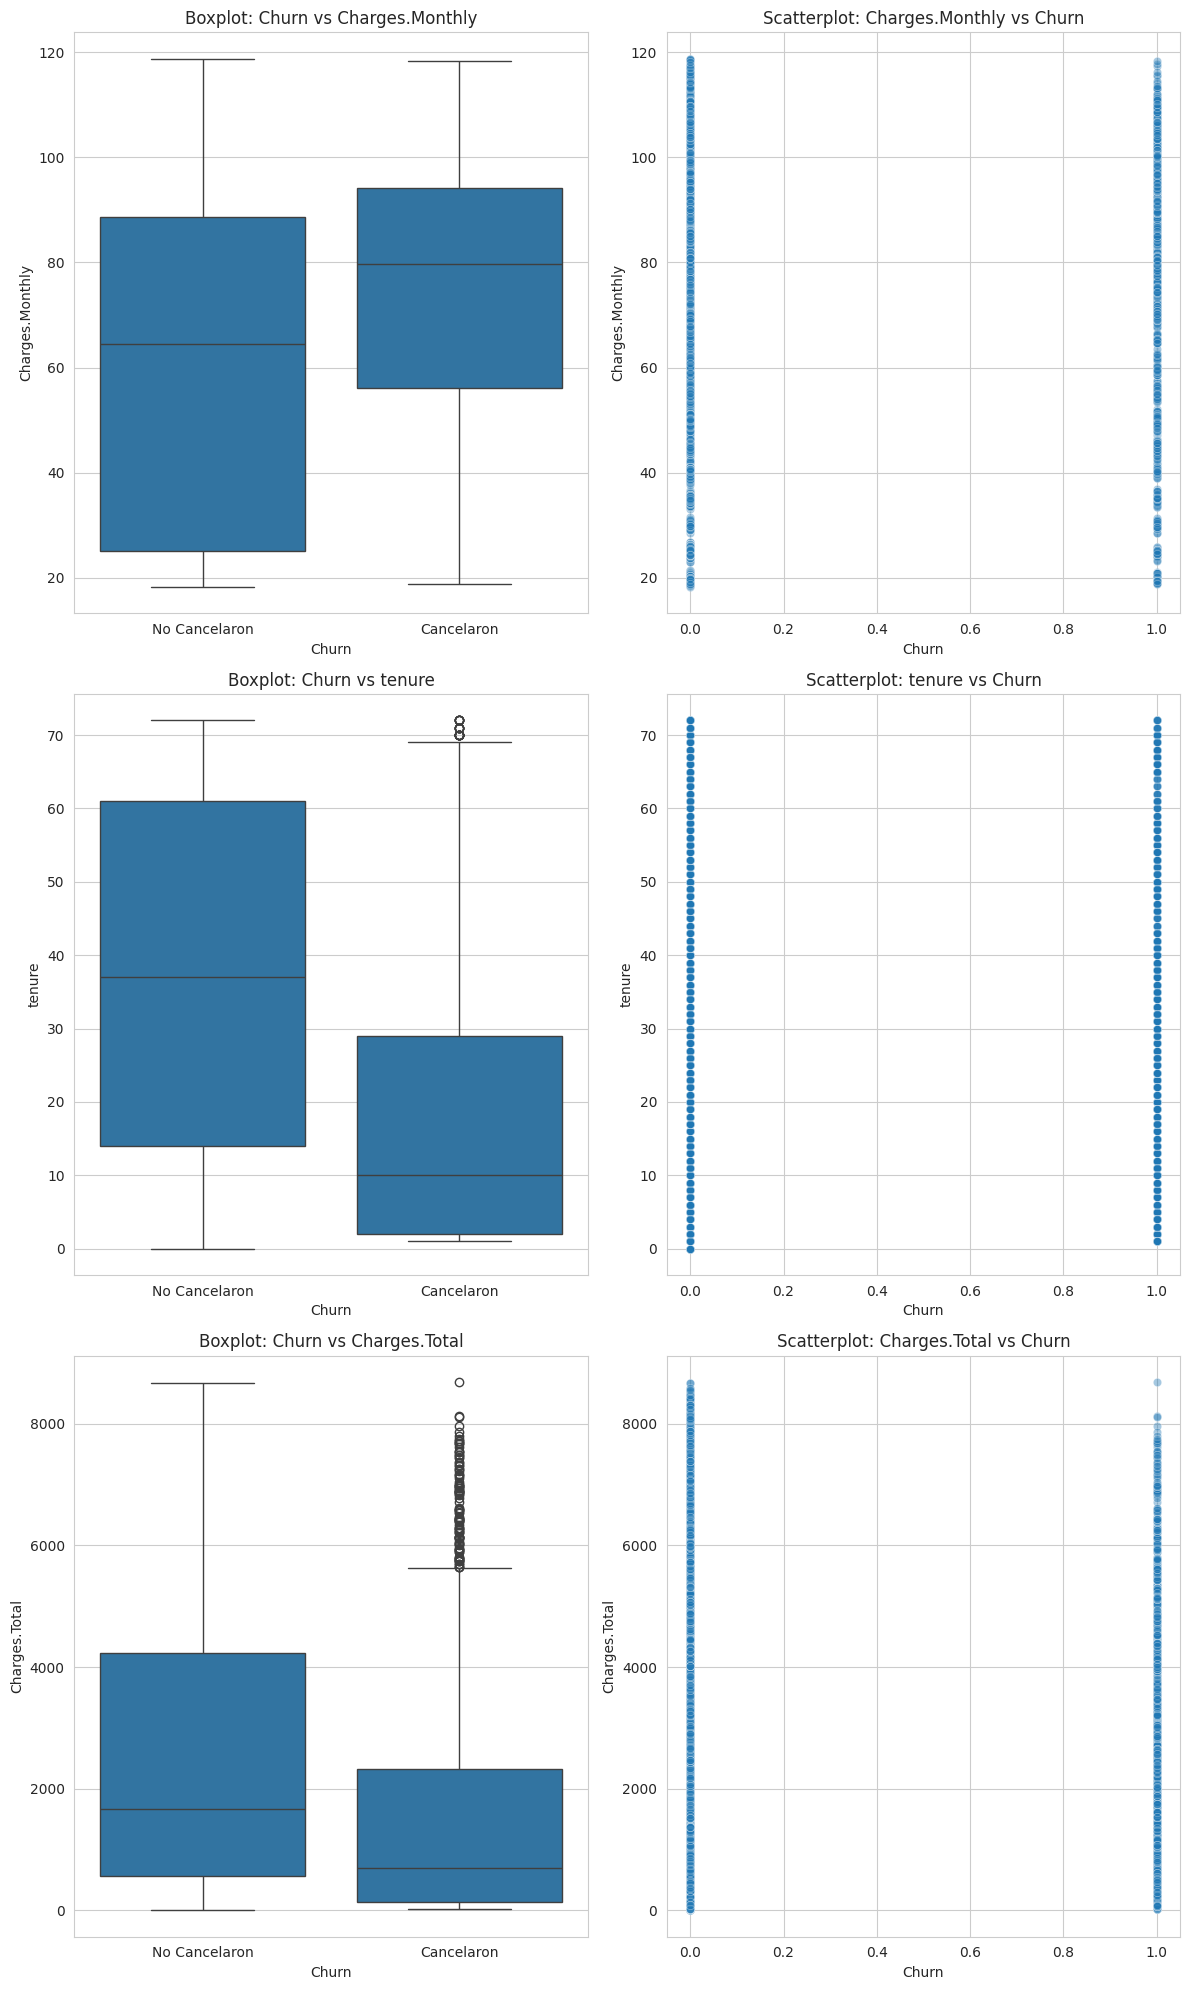

In [129]:
#Graficando las relaciones con mayor correlacion con la variable resultante
variables_explicativas = ["Charges.Monthly", "tenure", "Charges.Total"]

fig, axes = plt.subplots(3, 2, figsize=(12, 20))

for i, var in enumerate(variables_explicativas):

    # Boxplot
    sns.boxplot(x="Churn", y=var, data=df_codificados, ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot: Churn vs {var}")
    axes[i, 0].set_xticks([0,1])
    axes[i, 0].set_xticklabels(["No Cancelaron", "Cancelaron"])

    # Scatterplot
    sns.scatterplot(y=var, x="Churn", data=df_codificados, ax=axes[i, 1], alpha=0.4)
    axes[i, 1].set_title(f"Scatterplot: {var} vs Churn")

plt.tight_layout()
plt.show()

#🤖 Modelado Predictivo

#📋 Interpretación y Conclusiones

## Introducción

El objetivo de este análisis es estudiar el problema de evasión de clientes (Churn) en Telecom X. La evasión ocurre cuando un cliente decide cancelar su servicio.

Comprender los factores que influyen en este comportamiento es importante para las empresas, ya que retener clientes suele ser más económico que adquirir nuevos. A través del análisis de datos se busca identificar patrones que permitan entender qué características están asociadas con una mayor probabilidad de cancelación.

---

## Limpieza y Tratamiento de Datos

Para preparar los datos se realizaron varias etapas de limpieza y transformación:

- Se importaron los datos desde un archivo JSON utilizando pandas.
- Se normalizaron las columnas anidadas como `customer`, `phone`, `internet` y `account`.
- Se revisaron los tipos de datos del DataFrame para asegurar su correcta interpretación.
- Se reemplazaron valores vacíos en la columna **Charges.Total** para permitir su conversión a tipo numérico.
- Se transformaron variables booleanas de tipo **Yes/No** a valores binarios **1 y 0**.
- Se creó una nueva variable llamada **charges.daily** para representar el gasto diario del cliente.

Estos pasos permitieron obtener un dataset limpio y listo para el análisis exploratorio.

---

## Análisis Exploratorio de Datos

Durante el análisis exploratorio se realizaron diferentes visualizaciones para entender el comportamiento de los clientes.

Se analizaron aspectos como:

- Distribución general de clientes que cancelaron el servicio.
- Evasión de clientes según **género**.
- Evasión según **tipo de contrato**.
- Evasión según **método de pago**.

Además, se analizaron variables numéricas como:

- **Tenure (tiempo de permanencia del cliente)**  
- **Total de cargos acumulados**

A través de gráficos como **countplots y boxplots** se identificaron patrones que permiten comprender mejor el comportamiento de los clientes.

---

## Conclusiones e Insights

A partir del análisis se identificaron algunos patrones importantes:

- Los clientes con **contratos mensuales** presentan una mayor tasa de evasión.
- Los clientes con **menor tiempo de permanencia (tenure)** tienen mayor probabilidad de cancelar el servicio.
- Algunos métodos de pago parecen estar más asociados con la cancelación.
- Los clientes que permanecen más tiempo en la empresa tienden a acumular mayores cargos totales.

Estos resultados sugieren que la etapa inicial de la relación con el cliente es crítica para su fidelización.

---

## Recomendaciones

Basado en los hallazgos obtenidos, se proponen las siguientes recomendaciones:

- Implementar estrategias de fidelización para clientes nuevos.
- Promover contratos de mayor duración para reducir la evasión.
- Analizar los métodos de pago asociados con mayor churn.
- Desarrollar modelos predictivos que permitan identificar clientes con alto riesgo de cancelación.

Aplicar estas estrategias podría ayudar a mejorar la retención de clientes y reducir la evasión en la empresa.